# NB01 — Growth Curve Parsing and Fitting

**Project**: `genotype_to_phenotype_enigma`  
**Dependencies**: `src/curve_fitting.py`, `src/batch_fit.py`  
**Runtime**: ~7 minutes for all 303 bricks on JupyterHub

## Goal

Convert the 303 ENIGMA high-throughput growth plates into a tidy parameter table suitable for downstream modeling. Each well → one growth curve → one row of fitted parameters plus QC flags.

## Pipeline

1. **Read each brick** via Spark SQL. The 303 `ddt_brick*` tables have a slightly heterogeneous schema — a few columns (pH, temperature) are missing in some bricks. `batch_fit.py._build_select` handles this by introspecting each brick's columns and emitting `NULL AS <alias>` for missing fields.
2. **Group by (well, replicate)** — one well on one plate is one growth curve.
3. **Fit modified Gompertz** (Zwietering et al. 1990): `OD(t) = od0 + A·exp(-exp((µ·e/A)(lag-t) + 1))` with data-driven initial guesses.
4. **Compute derived metrics**: AUC, diauxy peaks, death-phase slope, cryptic-growth score.
5. **Flag QC**: `no_growth` (OD range < 0.05), `monotone_violation` (> 20% max drop), `fit_ok` (R² > 0.8 AND RMSE < 10% of OD range).
6. **Save one parquet per brick** (resumable).

## Why Gompertz not Baranyi?

Gompertz parameters map cleanly to biologically meaningful (A, µmax, lag, od0). Baranyi fits short-lag phases marginally better but doubles parameter count and creates identifiability issues. For downstream interpretable modeling we prefer stable parameters; Baranyi can be a follow-up refinement pass for low-R² wells.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from curve_fitting import fit_curve, gompertz, is_edge_well

pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 200)

PARAMS_DIR = Path('../data/growth_parameters')
FIG = Path('../figures')


## 1. Load all per-brick fitted parameters

In [2]:
files = sorted(PARAMS_DIR.glob('Brick*.parquet'))
print(f'Parameter files on disk: {len(files)}')
dfs = [pd.read_parquet(f) for f in files]
params = pd.concat(dfs, ignore_index=True)
print(f'Total fitted curves: {len(params):,}')
print(f'Unique strains: {params.strain.nunique()}')
print(f'Unique bricks: {params.brick_id.nunique()}')
params.to_parquet('../data/growth_parameters_all.parquet', index=False)
print(f'\nSaved growth_parameters_all.parquet ({len(params):,} rows)')


Parameter files on disk: 303


Total fitted curves: 27,632
Unique strains: 123
Unique bricks: 303

Saved growth_parameters_all.parquet (27,632 rows)


## 2. Corpus-wide QC summary

In [3]:
qc = pd.DataFrame({
    'Total curves': [len(params)],
    'Fit OK': [int(params.fit_ok.sum())],
    'No growth': [int(params.no_growth.sum())],
    'Monotone violation': [int(params.monotone_violation.sum())],
    'Fit failed': [int((~params.fit_ok & ~params.no_growth).sum())],
    'Edge wells': [int(params.edge_well.sum())],
    '% fit ok': [f'{100 * params.fit_ok.mean():.1f}%'],
}).T
qc.columns = ['count']
qc


,count
Total curves,27632
Fit OK,9861
No growth,15227
Monotone violation,18599
Fit failed,2544
Edge wells,10771
% fit ok,35.7%


In [4]:
# QC breakdown by strain (top 20 by curve count)
by_strain = (
    params.groupby('strain')
    .agg(
        n_curves=('fit_ok', 'size'),
        n_ok=('fit_ok', 'sum'),
        pct_ok=('fit_ok', lambda x: 100 * x.mean()),
        median_mu=('mu_fit', lambda x: x.dropna().median()),
        median_lag=('lag_fit', lambda x: x.dropna().median()),
        median_A=('A_fit', lambda x: x.dropna().median()),
    )
    .sort_values('n_curves', ascending=False)
    .head(20)
    .round(3)
)
by_strain


,n_curves,n_ok,pct_ok,median_mu,median_lag,median_A
strain,,,,,,
FW300-N2F2,458,236,51.528,0.034,9.119,0.184
FW300-N2E2,456,197,43.202,0.038,10.885,0.250
GW460-11-11-14-LB1,456,139,30.482,0.012,13.933,0.145
GW101-3H06,454,220,48.458,0.033,9.314,0.318
FW300-N2E3,454,276,60.793,0.054,10.394,0.460
GW821-FHT04C10,446,158,35.426,0.016,34.287,0.456
GW821-FHT01B05,426,125,29.343,0.005,8.651,0.128
GW821-FHT02D03,384,81,21.094,0.018,8.831,0.083
GW822-FHT03C01,384,74,19.271,0.030,13.878,0.221


## 3. Parameter distributions (fit_ok subset)

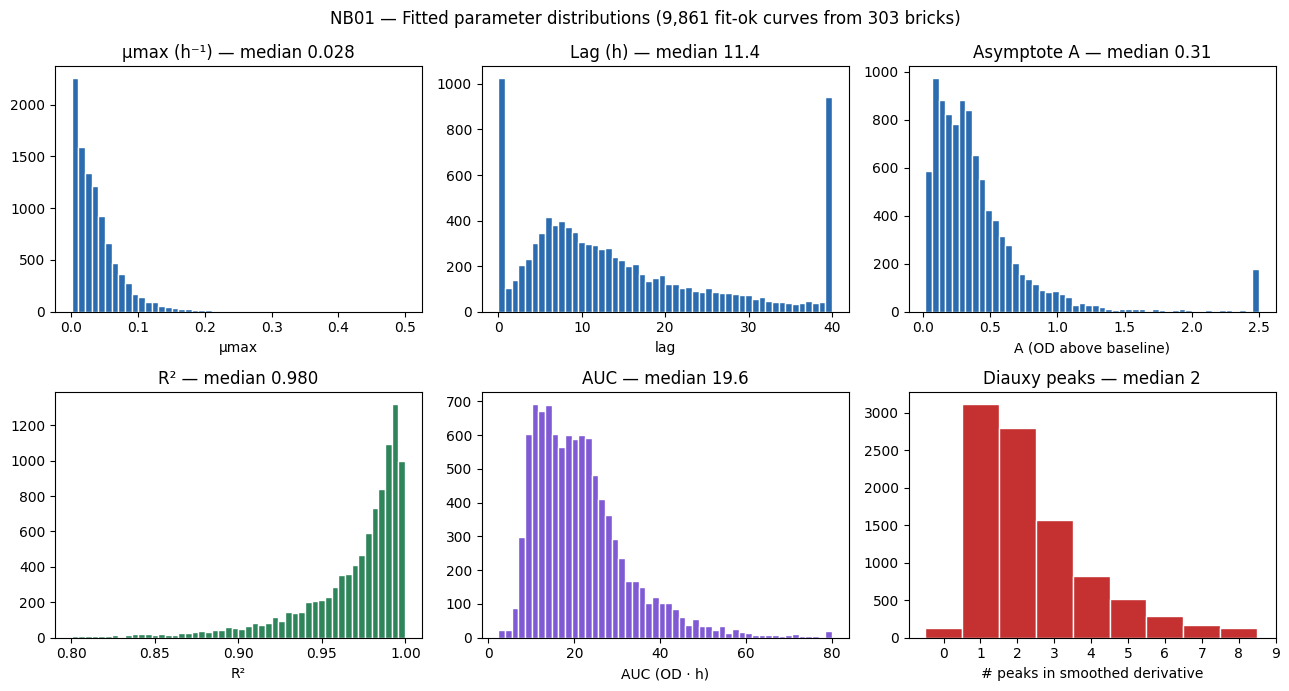

In [5]:
ok = params[params.fit_ok]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

axes[0,0].hist(ok.mu_fit.clip(upper=0.5), bins=50, color='#2b6cb0', edgecolor='white')
axes[0,0].set_title(f'µmax (h⁻¹) — median {ok.mu_fit.median():.3f}')
axes[0,0].set_xlabel('µmax')

axes[0,1].hist(ok.lag_fit.clip(upper=40), bins=50, color='#2b6cb0', edgecolor='white')
axes[0,1].set_title(f'Lag (h) — median {ok.lag_fit.median():.1f}')
axes[0,1].set_xlabel('lag')

axes[0,2].hist(ok.A_fit.clip(upper=2.5), bins=50, color='#2b6cb0', edgecolor='white')
axes[0,2].set_title(f'Asymptote A — median {ok.A_fit.median():.2f}')
axes[0,2].set_xlabel('A (OD above baseline)')

axes[1,0].hist(ok.r2, bins=50, color='#2f855a', edgecolor='white')
axes[1,0].set_title(f'R² — median {ok.r2.median():.3f}')
axes[1,0].set_xlabel('R²')

axes[1,1].hist(ok.auc.clip(upper=80), bins=50, color='#805ad5', edgecolor='white')
axes[1,1].set_title(f'AUC — median {ok.auc.median():.1f}')
axes[1,1].set_xlabel('AUC (OD · h)')

axes[1,2].hist(ok.n_diauxy_peaks, bins=np.arange(0, 10) - 0.5,
               color='#c53030', edgecolor='white')
axes[1,2].set_title(f'Diauxy peaks — median {int(ok.n_diauxy_peaks.median())}')
axes[1,2].set_xlabel('# peaks in smoothed derivative')
axes[1,2].set_xticks(range(0, 10))

plt.suptitle(f'NB01 — Fitted parameter distributions ({len(ok):,} fit-ok curves from {params.brick_id.nunique()} bricks)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG / 'NB01_parameter_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Example curve fits (Brick0000964 — FW300-N2E3)

12 representative wells from the primary anchor strain. Generated in the validation step from raw timepoint data.

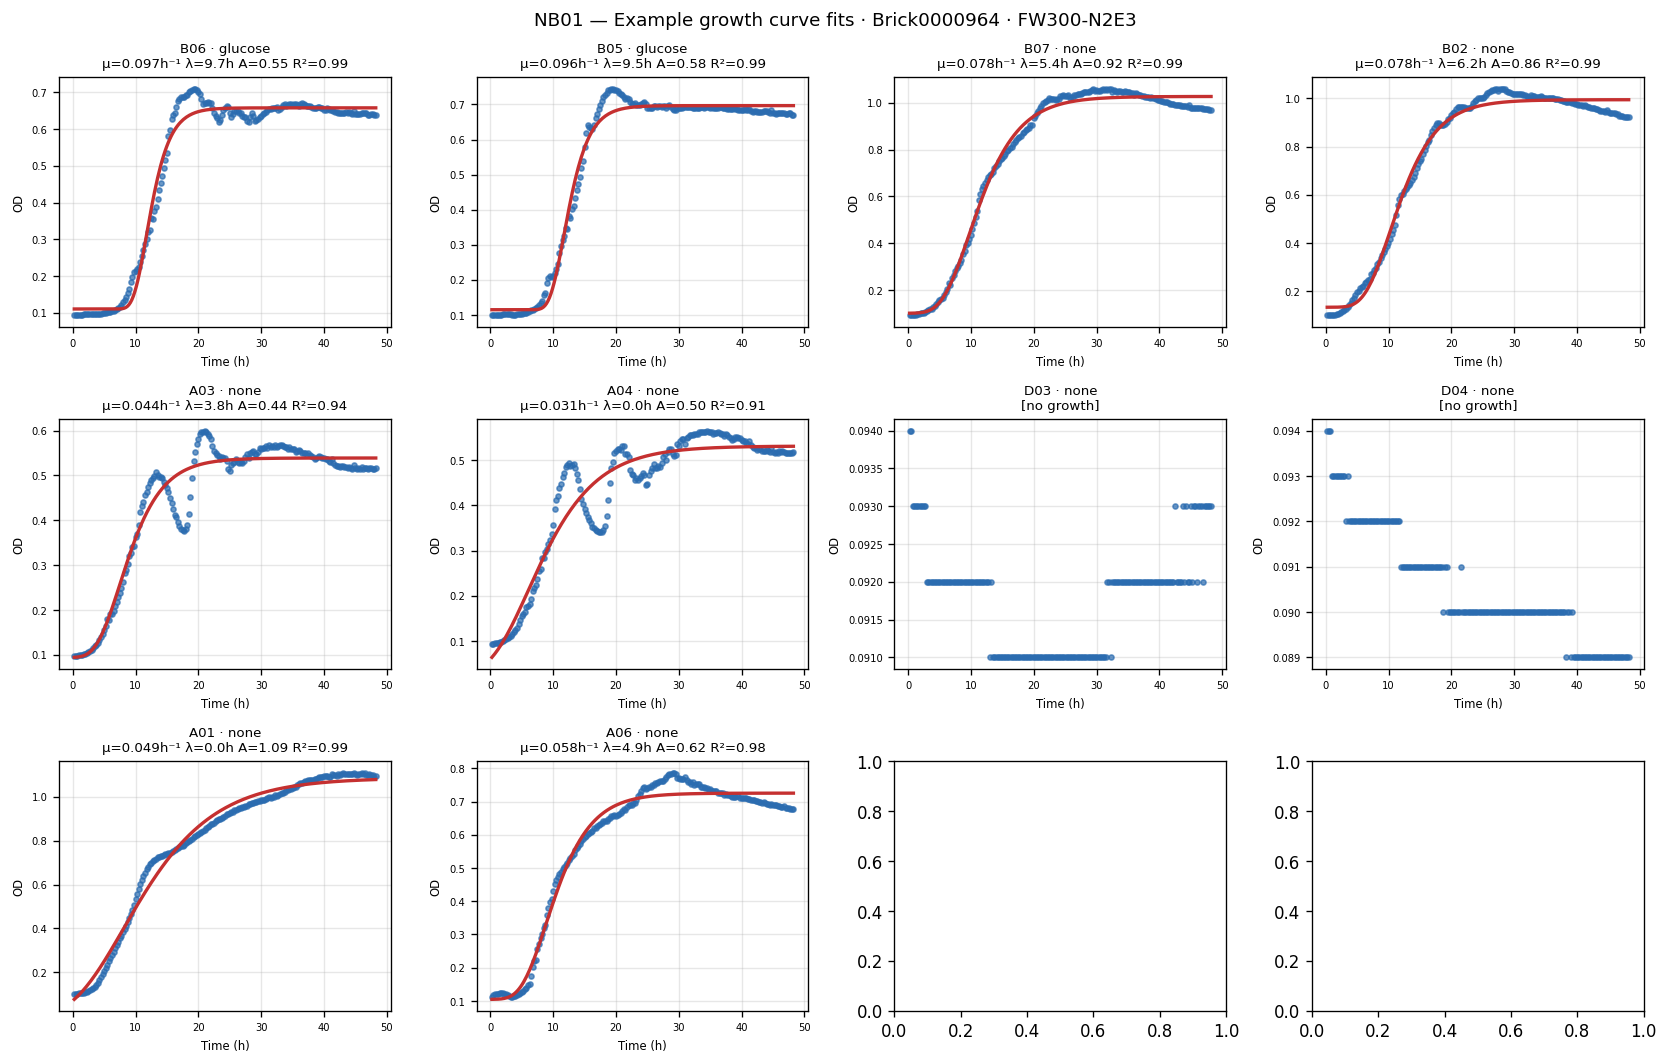

In [6]:
from IPython.display import Image
Image(filename=str(FIG / 'NB01_curve_fit_examples.png'))


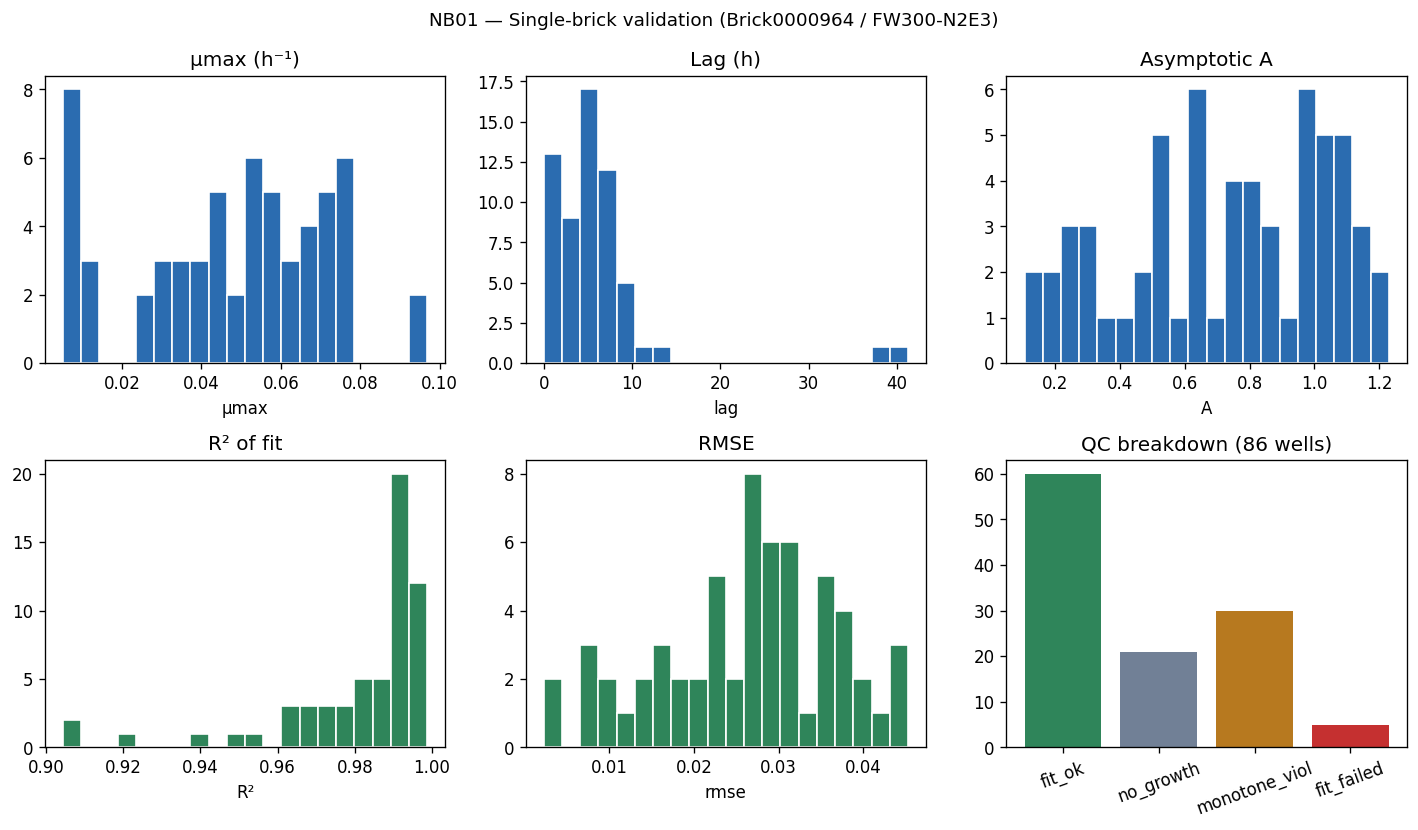

In [7]:
Image(filename=str(FIG / 'NB01_single_brick_qc.png'))


## 5. QC pass rate for Tier-1 FB anchor strains

In [8]:
FB_ANCHORS = ['FW300-N1B4','FW300-N2E2','FW300-N2E3','FW300-N2F2',
              'GW456-L13','GW460-11-11-14-LB5','GW101-3H11','FW507-4G11']
anchor = params[params.strain.isin(FB_ANCHORS)]
per_anchor = (
    anchor.groupby('strain')
    .agg(
        n_curves=('fit_ok', 'size'),
        n_ok=('fit_ok', 'sum'),
        pct_ok=('fit_ok', lambda x: 100 * x.mean()),
        n_no_growth=('no_growth', 'sum'),
        median_mu=('mu_fit', lambda x: x.dropna().median()),
        median_A=('A_fit', lambda x: x.dropna().median()),
        median_lag=('lag_fit', lambda x: x.dropna().median()),
    )
    .round(3)
    .sort_values('n_curves', ascending=False)
)
per_anchor


,n_curves,n_ok,pct_ok,n_no_growth,median_mu,median_A,median_lag
strain,,,,,,,
FW300-N2F2,458,236,51.528,144,0.034,0.184,9.119
FW300-N2E2,456,197,43.202,193,0.038,0.250,10.885
FW300-N2E3,454,276,60.793,145,0.054,0.460,10.394
GW460-11-11-14-LB5,362,85,23.481,216,0.032,0.294,8.692
FW300-N1B4,360,207,57.500,127,0.040,0.359,10.974
GW456-L13,360,201,55.833,139,0.033,0.240,8.910
GW101-3H11,192,43,22.396,130,0.012,0.125,20.105
FW507-4G11,192,108,56.250,71,0.020,0.270,9.256


## 6. Corpus-wide QC figure

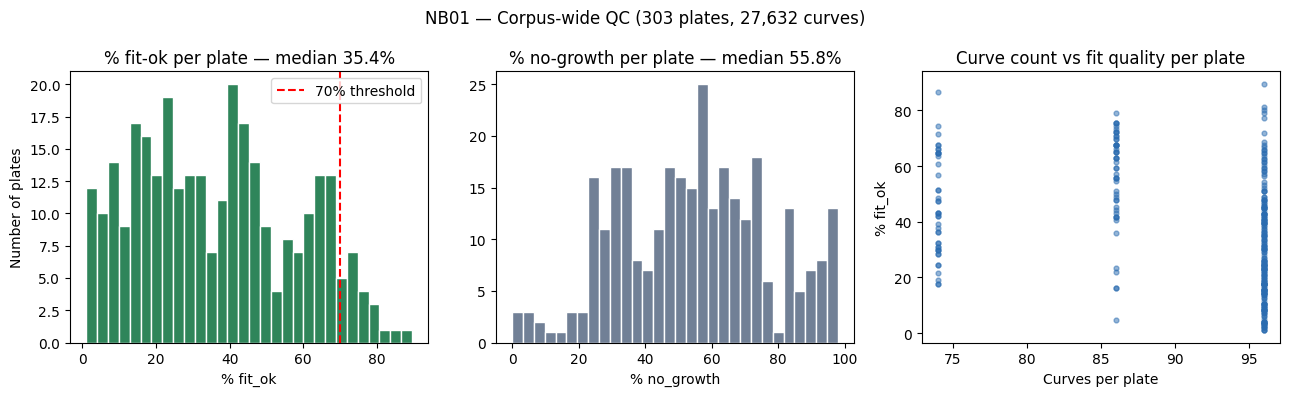

In [9]:
brick_qc = (
    params.groupby('brick_id')
    .agg(
        n_curves=('fit_ok', 'size'),
        pct_ok=('fit_ok', lambda x: 100 * x.mean()),
        pct_no_growth=('no_growth', lambda x: 100 * x.mean()),
    )
    .reset_index()
)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(brick_qc.pct_ok, bins=30, color='#2f855a', edgecolor='white')
axes[0].set_title(f'% fit-ok per plate — median {brick_qc.pct_ok.median():.1f}%')
axes[0].set_xlabel('% fit_ok')
axes[0].set_ylabel('Number of plates')
axes[0].axvline(70, color='red', ls='--', label='70% threshold')
axes[0].legend()

axes[1].hist(brick_qc.pct_no_growth, bins=30, color='#718096', edgecolor='white')
axes[1].set_title(f'% no-growth per plate — median {brick_qc.pct_no_growth.median():.1f}%')
axes[1].set_xlabel('% no_growth')

axes[2].scatter(brick_qc.n_curves, brick_qc.pct_ok, alpha=0.5, color='#2b6cb0', s=12)
axes[2].set_xlabel('Curves per plate')
axes[2].set_ylabel('% fit_ok')
axes[2].set_title('Curve count vs fit quality per plate')

plt.suptitle(f'NB01 — Corpus-wide QC ({params.brick_id.nunique()} plates, {len(params):,} curves)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG / 'NB01_qc_summary.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. What this enables

`growth_parameters_all.parquet` now has one row per (brick, well, replicate) with fitted `(A, µmax, lag, od0)` plus `auc`, `death_slope`, `n_diauxy_peaks`, `cryptic_score`, and QC flags. Each row carries strain, media, molecule (with ChEBI ID), concentration, pH, and temperature where available. This is the **phenotype side** of the modeling table.

Next steps (NB02+):
- **NB02** — Condition canonicalization. Map molecule+concentration+pH+media → canonical key matchable to `globalusers_carbon_source_phenotypes` and FB `experiment.condition_1`. ChEBI IDs make this much cleaner than naive strings.
- **NB03** — Coverage atlas. Join parameter table × canonical conditions × data availability → identify the dense anchor set.
- **NB04+** — Predictor training.

## Known limitations

- **Gompertz alone**: Curves with very short lag or strong death phase get squeezed. Baranyi refinement possible in a follow-up pass.
- **Replicate pooling deferred**: Replicate index is part of the curve key but replicates aren't averaged yet. That's NB03's job.
- **Monotone violation threshold at 20%** is aggressive — may reject genuinely noisy real curves. Consider soft weighting.
- **Edge wells flagged but not excluded**: decision deferred to NB03 based on replicate consistency.
- **Diauxy detection is noise-prone**: find_peaks with 10% prominence gives counts but false positives from measurement noise are common. Visual spot-check recommended before using as a modeling target.
